In [1]:
# import statements & checking for cuda
import torch
torch.set_float32_matmul_precision('high')
from ddpm.trainer import LitDDPM
from ddpm.unet import Unet
from helpers import first_radio_galaxy_transform_val, proj_hermitian
from torch.utils.data import DataLoader
from dataset.radio_galaxy_dataset.firstgalaxydata import FIRSTGalaxyData

import numpy as np
from ddrm.svd_replacement import Fourier2D_mask, Fourier2D_weight
from pathlib import Path
import matplotlib.cm as cm
import matplotlib.pyplot as plt
import matplotlib.colors as colors
import pandas as pd
from matplotlib.colors import LogNorm

device = torch.device('cuda')

print("CUDA available:", torch.cuda.is_available())
if torch.cuda.is_available():
    idx = torch.cuda.current_device()
    print("Current device:", idx)
    print("Name:", torch.cuda.get_device_name(idx))
    x = torch.randn(1, device=f"cuda:{idx}")
    print("Tensor device:", x.device)

import os

/user-environment/env/default/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


CUDA available: True
Current device: 0
Name: NVIDIA GH200 120GB
Tensor device: cuda:0


In [2]:
normalize = lambda x : (x - x.min()) /  (x.max() - x.min())

def ft(img):
    return np.fft.ifftshift(np.fft.fft2(np.fft.fftshift(img)))

def ift(vis):
    return (np.fft.fftshift(np.fft.ifft2(np.fft.fftshift(vis)))).real

class Norm:
    def __init__(self, x):
        self.shift = np.min(x)
        self.scale = np.max(x)
    def normalize(self,x):
        return (x-self.shift)/(self.scale-self.shift)
    def invert(self,x):
        return x*(self.scale-self.shift) + self.shift

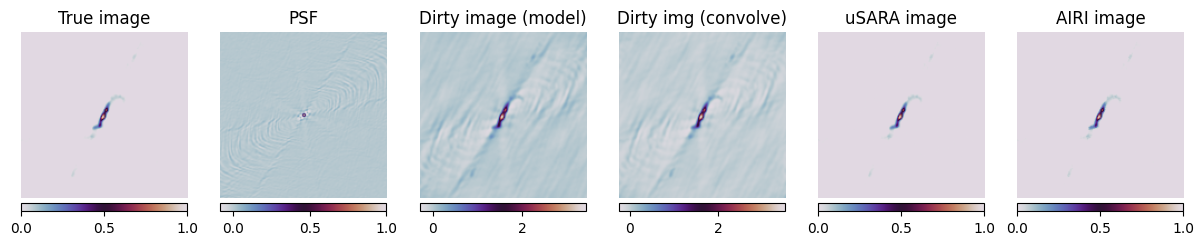

In [3]:
# input data
true_image = np.load("./data_compare/true_image_2.npy")

from astropy.io import fits
uSARA_image = fits.getdata("./data_compare/uSARA_heuRegScale_1.0_model_image.fits").astype(float)
AIRI_image  = fits.getdata("./data_compare/AIRI_heuScale_1.0_model_image.fits").astype(float)
nufft_dirty = fits.getdata("./data_compare/dirty.fits").astype(float)
nufft_psf   = fits.getdata("./data_compare/psf.fits").astype(float)


#rescale the input image to go from 0 to 1
shift = np.min(true_image)
scale = np.max(true_image)
truth_norm = Norm(true_image)
true_image = truth_norm.normalize(true_image)

# rescale the psf so that the max is 1
nufft_psf /= np.max(nufft_psf)
sampling_weights = np.abs(ft(nufft_psf))


lognorm = colors.SymLogNorm(linthresh=0.0001,vmin=0,vmax=1)
linnorm = colors.Normalize(vmin=0,vmax=1)

fig, ax = plt.subplots(1,6, figsize=(15,7))
ax = ax.flatten()
cbar = [None]*len(ax)

cbar[0] = ax[0].imshow(true_image,norm = linnorm, cmap = "twilight")
ax[0].set_title("True image")
cbar[1] = ax[1].imshow(nufft_psf,cmap = "twilight")
ax[1].set_title("PSF")
cbar[2] = ax[2].imshow(nufft_dirty,cmap = "twilight")
ax[2].set_title("Dirty image (model)")

cbar[3] = ax[3].imshow(ift(ft(true_image)*sampling_weights), cmap = "twilight")
ax[3].set_title("Dirty img (convolve)")

cbar[4] = ax[4].imshow(uSARA_image,norm = linnorm,cmap = "twilight")
ax[4].set_title("uSARA image")
cbar[5] = ax[5].imshow(AIRI_image,norm = linnorm,cmap = "twilight")
ax[5].set_title("AIRI image")

for i in range(len(ax)):
    ax[i].set_axis_off()
    fig.colorbar(cbar[i], ax=ax[i],  pad = 0.01, orientation="horizontal")


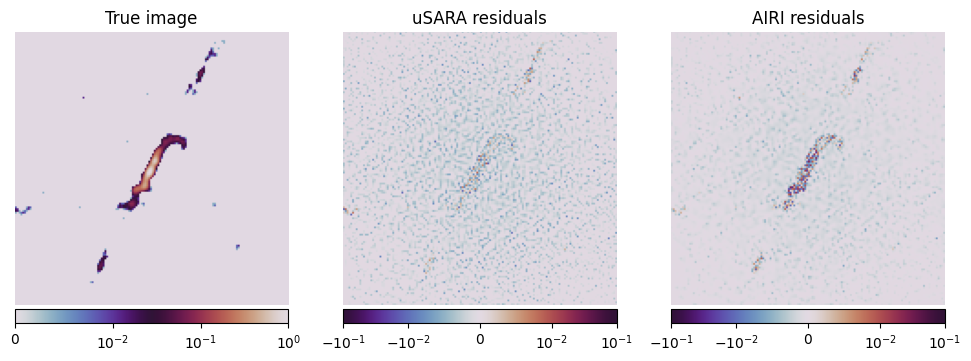

In [4]:
fig, ax = plt.subplots(1,3, figsize=(12,5))
ax = ax.flatten()
cbar = [None]*len(ax)
lognorm = colors.SymLogNorm(linthresh=0.01,vmin=0,vmax=1)
resnorm = colors.SymLogNorm(linthresh=0.01,vmin=-.1,vmax=.1)
cbar[0] = ax[0].imshow(true_image,norm = lognorm, cmap = "twilight")
ax[0].set_title("True image")
cbar[1] = ax[1].imshow(true_image-uSARA_image,norm = resnorm,cmap = "twilight_shifted")
ax[1].set_title("uSARA residuals")
cbar[2] =  ax[2].imshow(true_image-AIRI_image,norm = resnorm,cmap = "twilight_shifted")
ax[2].set_title("AIRI residuals")
for i in range(len(ax)):
    ax[i].set_axis_off()
    fig.colorbar(cbar[i], ax=ax[i],  pad = 0.01, orientation="horizontal")


In [5]:
# the simulated observation
from scipy.io import loadmat

meas = loadmat('./data_compare/gal2_sim_data_150x150.mat')
for k, v in meas.items():
    if not k.startswith('__'):
        if max(v.shape) == 1:
            if type(v.item()) == str:
                print(f"{k}: {v.item()}")
            else:
                print(f"{k}: {v.item():.4e}")
        else:
            print(f"{k}: {v.shape}, {type(v)}")

y: (299325, 1), <class 'numpy.ndarray'>
nW: (299325, 1), <class 'numpy.ndarray'>
u: (299325, 1), <class 'numpy.ndarray'>
v: (299325, 1), <class 'numpy.ndarray'>
w: (299325, 1), <class 'numpy.ndarray'>
frequency: 1.0000e+09


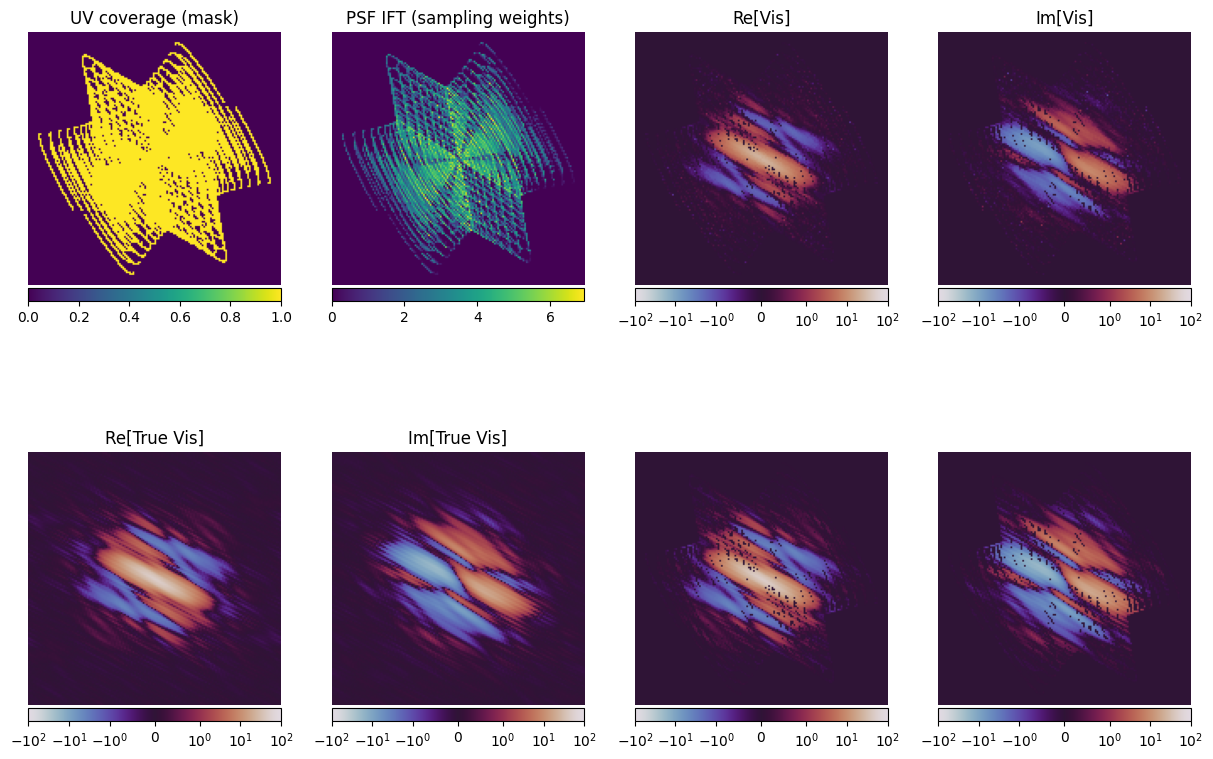

In [21]:
# Check the observation file

fig, axs = plt.subplots(2,4,figsize=(15,10))
axs = axs.flatten()
cbar = [None]*len(axs)

u_coords = meas['u'].ravel()
v_coords = meas['v'].ravel()
u_coords = np.hstack([u_coords,-1*u_coords])
v_coords = np.hstack([v_coords,-1*v_coords])
y_img = meas['y'].ravel()
y_img = np.hstack([np.conj(y_img),y_img])/2

hist_range = [[np.min(u_coords)*1.1, np.max(u_coords)*1.1], [np.min(v_coords)*1.1, np.max(v_coords)*1.1]]
uv_hist, x_edges, y_edges = np.histogram2d(u_coords,v_coords , range = hist_range, bins=150)
gridded_vis_re, _, _ = np.histogram2d(u_coords,v_coords, weights=y_img.real, range = hist_range, bins=150)
gridded_vis_im, _, _ = np.histogram2d(u_coords,v_coords, weights=y_img.imag, range = hist_range, bins=150)

gridded_vis = gridded_vis_re + 1j*gridded_vis_im
gridded_vis[uv_hist > 0] /= uv_hist[uv_hist > 0]
gridded_vis = np.rot90(gridded_vis, k=3)

mask = np.rot90(uv_hist > 0, k=3)

sampling_weights=sampling_weights*mask

cbar[0] = axs[0].imshow(mask)
axs[0].set_title("UV coverage (mask)")



cbar[1] = axs[1].imshow(sampling_weights)
axs[1].set_title("PSF IFT (sampling weights)")
cbar[2] =axs[2].imshow(gridded_vis.real, norm = colors.SymLogNorm(linthresh=1,vmin=-100,vmax=100),cmap = "twilight")
axs[2].set_title("Re[Vis]")
cbar[3] = axs[3].imshow(gridded_vis.imag, norm = colors.SymLogNorm(linthresh=1,vmin=-100,vmax=100),cmap = "twilight")
axs[3].set_title("Im[Vis]")

cbar[4] = axs[4].imshow(1-(sampling_weights==0))
axs[4].set_title("sampling weights mask")


true_vis = ft(true_image)
cbar[4] =axs[4].imshow(true_vis.real, norm = colors.SymLogNorm(linthresh=1,vmin=-100,vmax=100),cmap = "twilight")
axs[4].set_title("Re[True Vis]")
cbar[5] = axs[5].imshow(true_vis.imag, norm = colors.SymLogNorm(linthresh=1,vmin=-100,vmax=100),cmap = "twilight")
axs[5].set_title("Im[True Vis]")

cbar[6] = axs[6].imshow(true_vis.real*mask, norm = colors.SymLogNorm(linthresh=1,vmin=-100,vmax=100),cmap = "twilight")
cbar[7] = axs[7].imshow(true_vis.imag*mask, norm = colors.SymLogNorm(linthresh=1,vmin=-100,vmax=100),cmap = "twilight")




for i in range(len(axs)):
    axs[i].set_axis_off()
    if cbar[i]: fig.colorbar(cbar[i], ax=axs[i],  pad = 0.01, orientation="horizontal")

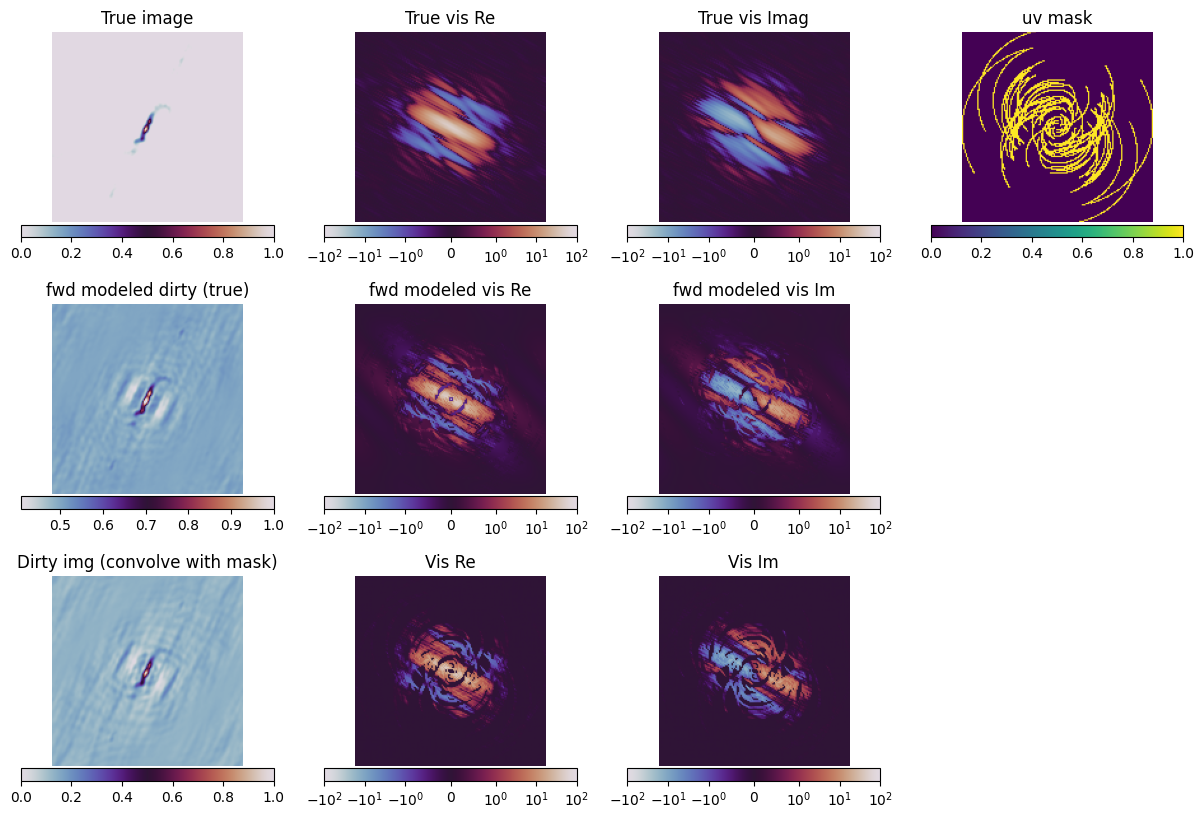

In [27]:
fig, axs = plt.subplots(3,4,figsize=(15,10))
axs = axs.flatten()
cbar = [None]*len(axs)

cbar[0] =axs[0].imshow(true_image, cmap = "twilight")
axs[0].set_title("True image")

vis_true = ft(true_image)
cbar[1] = axs[1].imshow(vis_true.real,norm = colors.SymLogNorm(linthresh=1,vmin=-100,vmax=100),cmap = "twilight")
axs[1].set_title("True vis Re")
cbar[2] = axs[2].imshow(vis_true.imag,norm = colors.SymLogNorm(linthresh=1,vmin=-100,vmax=100),cmap = "twilight")
axs[2].set_title("True vis Imag")


cbar[3] = axs[3].imshow(mask)
axs[3].set_title("uv mask")

# define the sampling operator used by DDRM

# sampling operator H
mask = np.load('uv_coverages/VLA_mask_150_100steps_uniform.npy')
#weights = torch.from_numpy(np.load('uv_coverages/VLA_mask_150_100steps_natural.npy'))
h1 = Fourier2D_mask(channels=1, img_dim=150, S=torch.from_numpy(mask.copy()), device=device)
#h1 = Fourier2D_weight(channels=1, img_dim=image_size, S=torch.from_numpy(sampling_weights), device=device)

def forward_model_dirty(x,sigma = 0):
    x = torch.from_numpy(normalize(x) * 2.0 - 1.0).float().reshape(1,150, 150)
    x_gpu = x.to(device)
    x_0 = x_gpu.unsqueeze(0).repeat(1, 1, 1, 1)
    y1_0 = h1.H(x_0)
    #y1_0 = y1_0 + sigma * proj_hermitian(torch.randn_like(y1_0) * np.sqrt(2))
    x_dirty = h1.H_pinv(y1_0).reshape(1,150,150).cpu()
    x_dirty = ((x_dirty + 1) / 2).clamp(0, 1)
    return y1_0,x_dirty

cbar[4] = axs[4].imshow(forward_model_dirty(true_image)[1][0,...],cmap = "twilight")
axs[4].set_title("fwd modeled dirty (true)")

vis_fwd_model = ft(forward_model_dirty(true_image)[1][0,...])
cbar[5] = axs[5].imshow(vis_fwd_model.real,norm = colors.SymLogNorm(linthresh=1,vmin=-100,vmax=100),cmap = "twilight")
axs[5].set_title("fwd modeled vis Re")
cbar[6] = axs[6].imshow(vis_fwd_model.imag,norm = colors.SymLogNorm(linthresh=1,vmin=-100,vmax=100),cmap = "twilight")
axs[6].set_title("fwd modeled vis Im")

img_tmp = ift(ft(true_image)*mask)
cbar[8] = axs[8].imshow(normalize(img_tmp), cmap = "twilight")
axs[8].set_title("Dirty img (convolve with mask)")

vis_tmp = ft(img_tmp)

cbar[9] =  axs[9].imshow(vis_tmp.real,norm = colors.SymLogNorm(linthresh=1,vmin=-100,vmax=100),cmap = "twilight")
axs[9].set_title("Vis Re")
cbar[10] =  axs[10].imshow(vis_tmp.imag,norm = colors.SymLogNorm(linthresh=1,vmin=-100,vmax=100),cmap = "twilight")
axs[10].set_title("Vis Im")

for i in range(len(axs)):
    axs[i].set_axis_off()
    if cbar[i]: fig.colorbar(cbar[i], ax=axs[i],  pad = 0.01, orientation="horizontal")


In [24]:
# defining the model

# the image size we use will be 150x150, as set by the pre-trained DDPM
image_size = 150

# define and load the pre-trained DDPM
net = Unet(1, 32, 4, 2, 256).to('cuda')
model = LitDDPM.load_from_checkpoint('/capstor/store/cscs/ska/sk031/last-v5.ckpt', unet=net)

Channel per encoder Depth
[32, 64, 128, 256, 512]


In [74]:

# number of DDRM sampling steps
# increase this number to improve the image reconstruction
num_steps = 1000

# for a single input image, we will denoise batch_size times
# increase this number to get more samples
batch_size = 1

# sigma is the amount of noise added to visibility space
sigma_0 = 0.01#0.1494

# the eta hyperparamt 
eta_A, eta_B, eta_C = 0.85, 1.0, 0.85

tensor([    0,     1,     2,  ..., 22497, 22498, 22499])


/tmp/ipykernel_156210/438668927.py:25: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  cbar[2] = ax[2].imshow(forward_model_dirty(true_image)[1][0,...]-true_image,cmap = "twilight")
/tmp/ipykernel_156210/438668927.py:32: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  cbar[5] = ax[5].imshow(forward_model_dirty(nufft_dirty)[1][0,...]-normalize(nufft_dirty),cmap = "twilight")


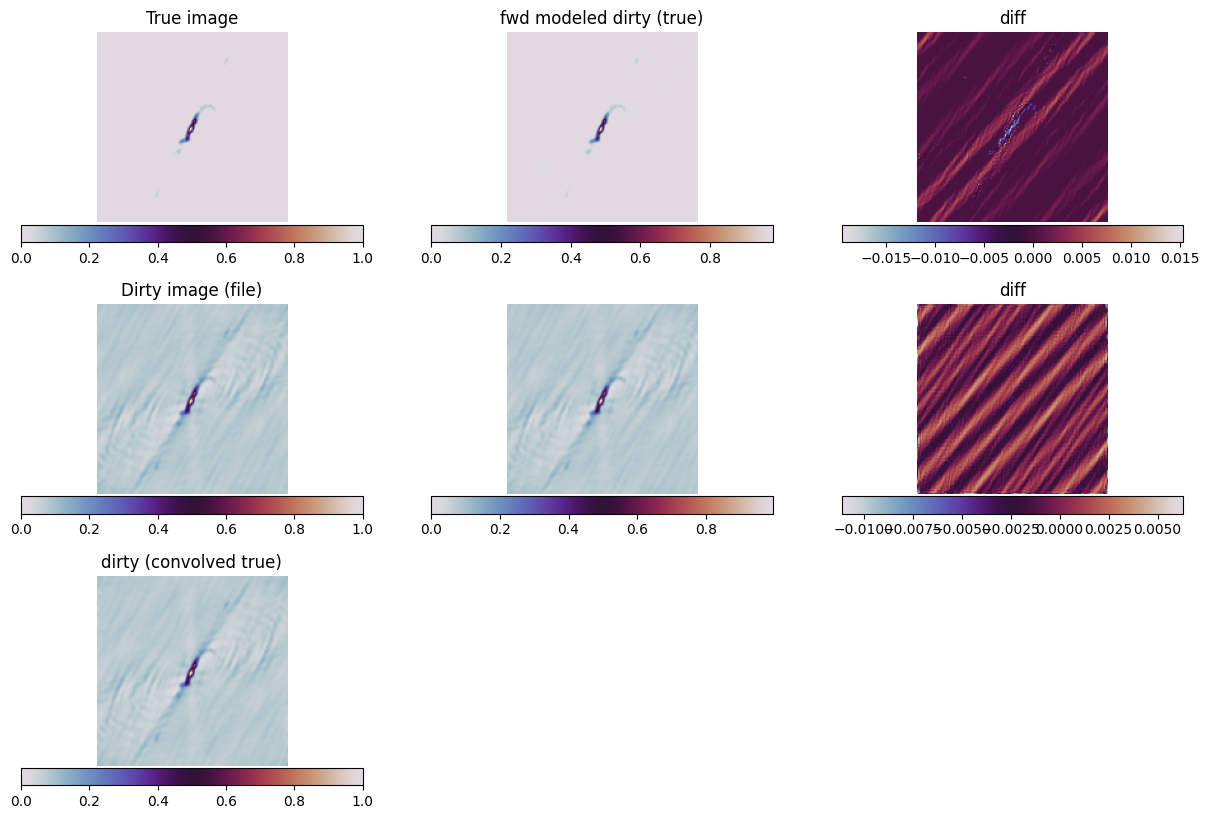

In [85]:
# format the true image x_0





x_dirty2 = np.absolute(np.fft.fftshift(np.fft.ifft2(np.fft.fftshift(sampling_weights))))
#x_dirty2 = (np.fft.fftshift(np.fft.ifft2(np.fft.fftshift(gridded_vis)))).real

fig, ax = plt.subplots(3,3, figsize=(15, 10))
ax = ax.flatten()
cbar = [None]*len(ax)
cbar[0] = ax[0].imshow(true_image,cmap = "twilight")
ax[0].set_title("True image")
cbar[1] = ax[1].imshow(forward_model_dirty(true_image)[1][0,...],cmap = "twilight")
ax[1].set_title("fwd modeled dirty (true)")
cbar[2] = ax[2].imshow(forward_model_dirty(true_image)[1][0,...]-true_image,cmap = "twilight")
ax[2].set_title("diff")

cbar[3] = ax[3].imshow(normalize(nufft_dirty),cmap = "twilight")
ax[3].set_title("Dirty image (file)")
cbar[4] = ax[4].imshow(forward_model_dirty(nufft_dirty)[1][0,...],cmap = "twilight")
ax[5].set_title("fwd modeled dirty (dirty)")
cbar[5] = ax[5].imshow(forward_model_dirty(nufft_dirty)[1][0,...]-normalize(nufft_dirty),cmap = "twilight")
ax[5].set_title("diff")


img_tmp = ift(ft(true_image)*sampling_weights)
cbar[6] = ax[6].imshow(normalize(img_tmp), cmap = "twilight")
ax[6].set_title("dirty (convolved true)")

for i in range(len(ax)):
    ax[i].set_axis_off()
    if cbar[i]: fig.colorbar(cbar[i], ax=ax[i],  pad = 0.01, orientation="horizontal")
        
plt.show()

In [ ]:
y1_0,x_dirty = forward_model_dirty(true_image,sigma_0)

# do the DDRM sampling
with model.ema.average_parameters():
    model.model.eval()...
    x_hat, inv = model.model.sample_ddrm_y0(
        image_size, num_steps, y1_0, x_dirty.shape[0], h1, sigma_0, eta_A, eta_B, eta_C
    )

# rescale the image estimate x_hat
x_hat = ((x_hat[-1] + 1) / 2).clamp(0, 1)      


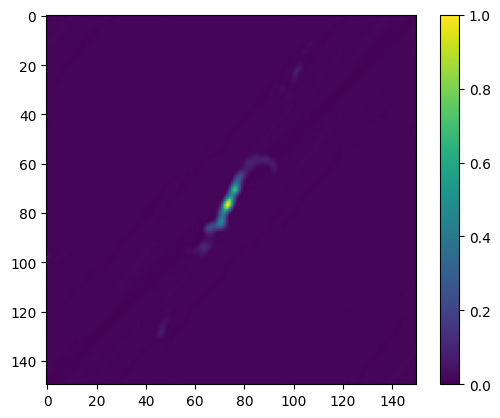

In [62]:
c = plt.imshow(normalize(inv.cpu().reshape(150,150)))
plt.colorbar(c)

torch.Size([1, 1, 150, 150])
tensor(0.) tensor(0.9822)


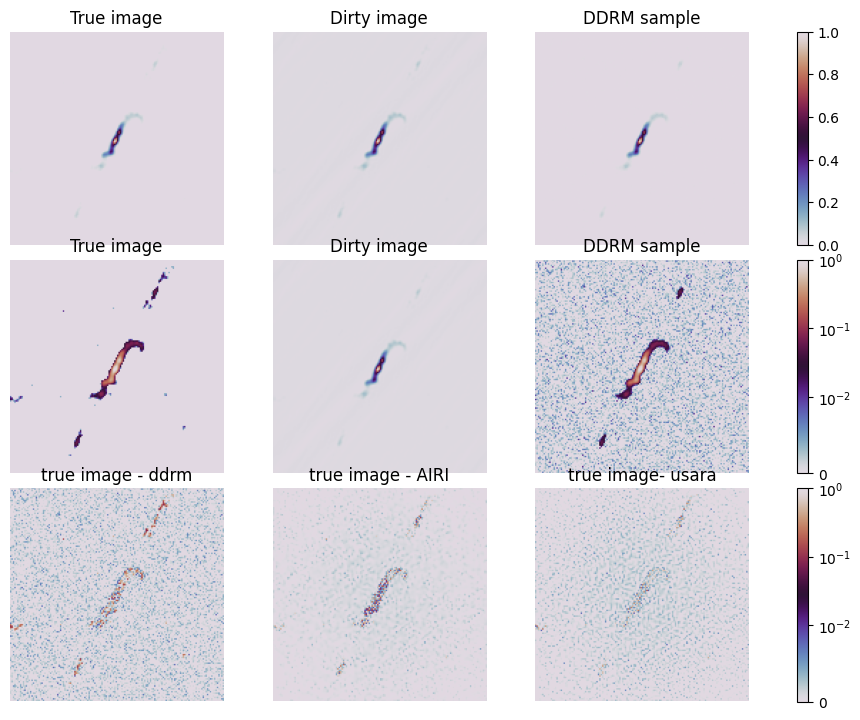

In [61]:
#make plots
fig, ax = plt.subplots(3,3, figsize=(10, 7))
ax = ax.flatten()
for a in ax: a.set_axis_off()
plt.tight_layout()

print(x_hat.shape)
ddrm_image = x_hat[0,...].reshape(image_size,image_size)
print(torch.min(ddrm_image),torch.max(ddrm_image))

cnorm = colors.SymLogNorm(linthresh=0.01,vmin=0,vmax=1)
linnorm = colors.Normalize(vmin=0,vmax=1)
#plt.subplots_adjust(left=0.06, right=0.99, top=0.99, bottom=0.1, wspace=0.0, hspace = 0.1)
pcm = ax[0].imshow(true_image,norm=linnorm,cmap = "twilight")
ax[0].set_title("True image")
ax[1].imshow(x_dirty[0,...],cmap = "twilight")
ax[1].set_title("Dirty image")
ax[2].imshow(ddrm_image,norm=linnorm,cmap = "twilight")
ax[2].set_title("DDRM sample")
plt.colorbar(pcm, ax=[ax[0],ax[1],ax[2]])

pcm = ax[3].imshow(true_image,norm=cnorm,cmap = "twilight")
ax[3].set_title("True image")
ax[4].imshow(x_dirty[0,...],cmap = "twilight")
ax[4].set_title("Dirty image")
ax[5].imshow(ddrm_image,norm=cnorm,cmap = "twilight")
ax[5].set_title("DDRM sample")
plt.colorbar(pcm, ax=[ax[3],ax[4],ax[5]])

ax[6].imshow(true_image-ddrm_image.numpy(),norm= colors.SymLogNorm(linthresh=0.01,vmin=-.1,vmax=.1),cmap = "twilight_shifted")
ax[6].set_title("true image - ddrm")
ax[7].imshow(true_image-AIRI_image,norm= colors.SymLogNorm(linthresh=0.01,vmin=-.1,vmax=.1),cmap = "twilight_shifted")
ax[7].set_title("true image - AIRI")
ax[8].imshow(true_image-uSARA_image,norm= colors.SymLogNorm(linthresh=0.01,vmin=-.1,vmax=.1),cmap = "twilight_shifted")
ax[8].set_title("true image- usara")
plt.colorbar(pcm, ax=[ax[6],ax[7],ax[8]])


plt.show()

In [114]:
ddrm_image.min()


tensor(0.0090)

In [115]:
ddrm_image.max()

tensor(0.9857)

In [116]:
true_image.min()

np.float64(0.0)

In [117]:
true_image.max()

np.float64(1.0)

In [118]:
uSARA_image.min()

np.float64(0.0)

In [119]:
uSARA_image.max()

np.float64(0.9918746948242188)

In [120]:
AIRI_image.min()

np.float64(0.0)

In [121]:
AIRI_image.max()

np.float64(0.9996822476387024)